In [1]:
from IPython.display import HTML

# standard imports
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *

### 2D Rotation Matrix

In [2]:
R = rot2(0.3)
R

array([[  0.9553,  -0.2955],
       [  0.2955,   0.9553]])

<Axes: xlabel='X', ylabel='Y'>

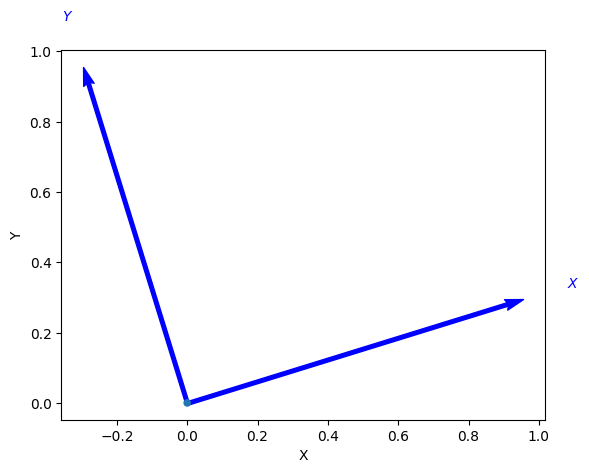

In [3]:
trplot2(R)

In [4]:
np.linalg.det(R)

0.9999999999999999

In [5]:
np.linalg.det(R @ R)

0.9999999999999998

In [6]:
from sympy import Symbol, Matrix, simplify

theta = Symbol('theta')
theta

theta

In [7]:
R = Matrix(rot2(theta)) # convert to Sympy matrix
R

Matrix([
[cos(theta), -sin(theta)],
[sin(theta),  cos(theta)]])

In [8]:
simplify(R * R)

Matrix([
[cos(2*theta), -sin(2*theta)],
[sin(2*theta),  cos(2*theta)]])

In [9]:
R.det()

sin(theta)**2 + cos(theta)**2

In [10]:
R.det().simplify()

1

### Matrix Exponential for Rotation

In [11]:
R = rot2(0.3)

In [12]:
L = linalg.logm(R)
L

array([[       0,     -0.3],
       [     0.3,        0]])

In [13]:
S = vex(L)
S

array([     0.3])

In [14]:
linalg.expm(L)

array([[  0.9553,  -0.2955],
       [  0.2955,   0.9553]])

In [15]:
linalg.expm(skew(S))

array([[  0.9553,  -0.2955],
       [  0.2955,   0.9553]])

### 2D Homogeneous Transformation Matrix

In [16]:
rot2(0.3)

array([[  0.9553,  -0.2955],
       [  0.2955,   0.9553]])

In [17]:
trot2(0.3)

array([[  0.9553,  -0.2955,        0],
       [  0.2955,   0.9553,        0],
       [       0,        0,        1]])

In [18]:
TA = transl2(1, 2) @ trot2(30, "deg")
TA

array([[   0.866,     -0.5,        1],
       [     0.5,    0.866,        2],
       [       0,        0,        1]])

[[<matplotlib.lines.Line2D at 0x21ba4365cf0>], Text(3, 2, ' P')]

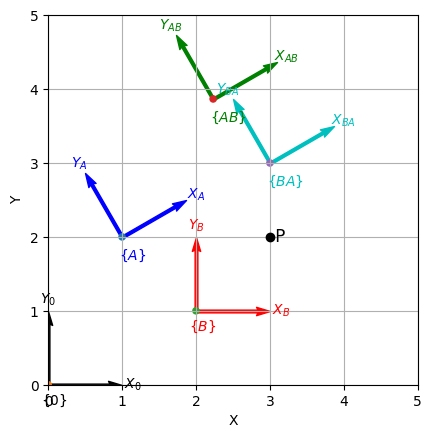

In [19]:
plotvol2([0, 5]) # new plot with both axes from 0 to 5
plt.grid(True)

trplot2(TA, frame="A", color="b")

T0 = transl2(0, 0)
trplot2(T0, frame="0", color="k") # reference frame

TB = transl2(2, 1)
trplot2(TB, frame="B", color="r")

TAB = TA @ TB
trplot2(TAB, frame="AB", color="g")

TBA = TB @ TA
trplot2(TBA, frame="BA", color="c")

P = np.array([3, 2])
plot_point(P, "ko", text="P")

In [20]:
np.linalg.inv(TA) @ np.hstack([P, 1])

array([   1.732,       -1,        1])

In [21]:
h2e(np.linalg.inv(TA) @ e2h(P))

array([[   1.732],
       [      -1]])

In [22]:
homtrans(np.linalg.inv(TA), P)

array([[   1.732],
       [      -1]])

#### Rotating a Coordinate Frame

<Axes: xlabel='X', ylabel='Y'>

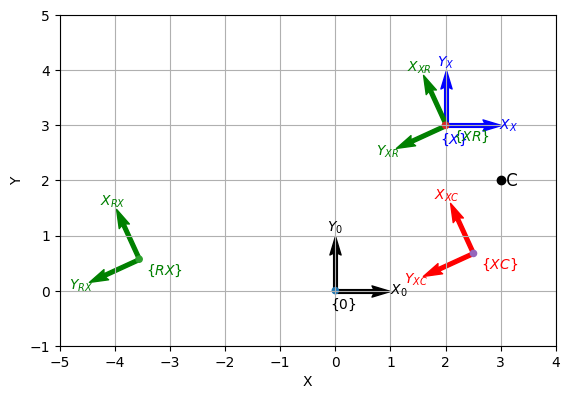

In [23]:
plotvol2([-5, 4, -1, 5])
plt.grid(True)

T0 = transl2(0, 0)
trplot2(T0, frame="0", color="k")

TX = transl2(2, 3)
trplot2(TX, frame="X", color="b")

TR = trot2(2)
trplot2(TR @ TX, frame="RX", color="g")
trplot2(TX @ TR, frame="XR", color="g")

C = np.array([3, 2])
plot_point(C, "ko", text="C")

TC = transl2(C) @ TR @ transl2(-C)
trplot2(TC @ TX, frame="XC", color="r")


#### Matrix Exponential for Pose

In [24]:
L = linalg.logm(TC)
L

array([[       0,       -2,        4],
       [       2,        0,       -6],
       [       0,        0,        0]])

In [27]:
S = vexa(L)
S

array([       4,       -6,        2])

In [28]:
linalg.expm(skewa(S))

array([[ -0.4161,  -0.9093,    6.067],
       [  0.9093,  -0.4161,   0.1044],
       [       0,        0,        1]])

#### 2D Twists

In [30]:
S = Twist2.UnitRevolute(C)
S

(2 -3; 1)

In [32]:
linalg.expm(skewa(2 * S.S))

array([[ -0.4161,  -0.9093,    6.067],
       [  0.9093,  -0.4161,   0.1044],
       [       0,        0,        1]])

In [35]:
S.exp(2)

  -0.4161   -0.9093    6.067     
   0.9093   -0.4161    0.1044    
   0         0         1         


In [36]:
S.pole

array([       3,        2])

In [37]:
S = Twist2.UnitPrismatic([0, 1])
S

(0 1; 0)

In [38]:
S.exp(2)

   1         0         0         
   0         1         2         
   0         0         1         


In [39]:
T = transl2(3, 4) @ trot2(0.5)
T

array([[  0.8776,  -0.4794,        3],
       [  0.4794,   0.8776,        4],
       [       0,        0,        1]])

In [40]:
S = Twist2(T)
S

(3.9372 3.1663; 0.5)

In [41]:
S.w

0.5

In [42]:
S.pole

array([  -3.166,    3.937])

In [43]:
S.exp(1)

   0.8776   -0.4794    3         
   0.4794    0.8776    4         
   0         0         1         
